**Heart Disease Prediction using Machine Learning**

Objective:
Develop classification models to predict whether a patient is likely to have heart disease based on medical attributes.

## Project Workflow

```text
Load Dataset
      │
      ▼
Data Understanding
      │
      ▼
Exploratory Data Analysis
      │
      ▼
Data Preprocessing
      │
      ▼
Train-Test Split
      │
      ▼
Feature Scaling
      │
      ▼
Model Training
      │
      ├── Logistic Regression
      ├── Decision Tree
      └── Random Forest
      │
      ▼
Model Evaluation
      │
      ▼
Model Comparison
      │
      ▼
Conclusion
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
heart_df = pd.read_csv("heart.csv")

In [3]:
heart_df.head()
heart_df.columns
heart_df["target"].nunique()
heart_df.shape
heart_df.info()
heart_df.describe()
heart_df.isnull().sum()
heart_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


np.int64(1)

## Exploratory Data Analysis

The purpose of EDA is to understand the dataset,
identify relationships between variables,
and detect potential issues before model training.

## Target Distribution

This visualization shows the balance between patients with and without heart disease. Understanding class distribution helps determine whether the dataset is balanced before training classification models.

In [4]:
X = heart_df.drop("target",axis= 1)
y = heart_df["target"]

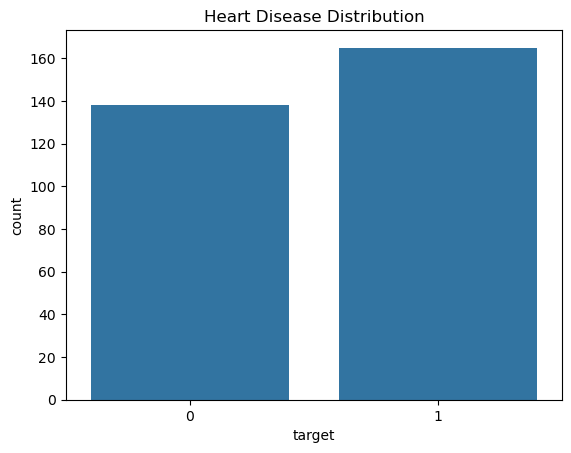

In [61]:
sns.countplot(x='target', data=heart_df)
plt.title("Heart Disease Distribution")
plt.savefig("images/Heart Disease Distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

The dataset is fairly balanced, making it suitable for classification.

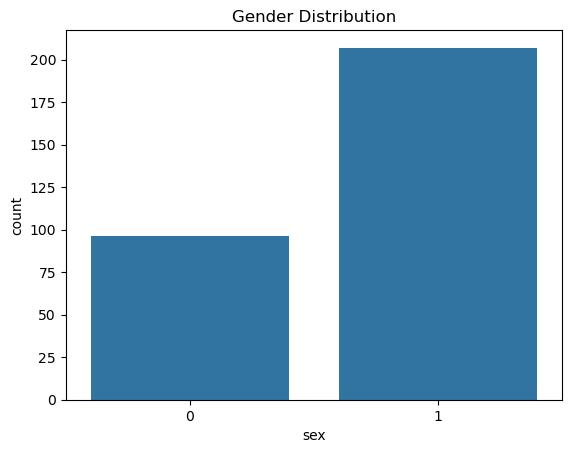

In [60]:
sns.countplot(x='sex', data=heart_df)
plt.title("Gender Distribution")
plt.savefig("images/Gender Distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

The dataset contains more male patients than female patients.

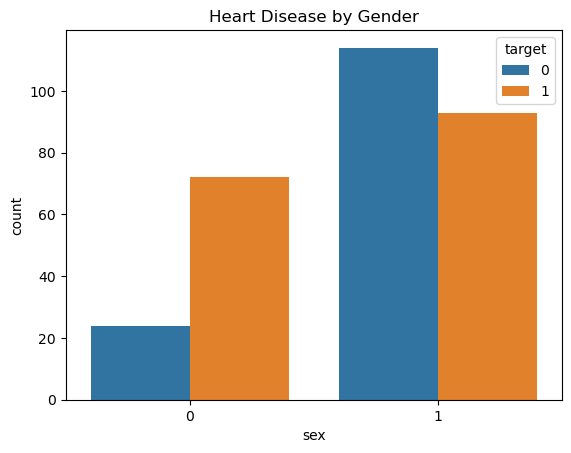

In [59]:
sns.countplot(x='sex', hue='target', data=heart_df)
plt.title("Heart Disease by Gender")
plt.savefig("images/Heart Disease by Gender.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

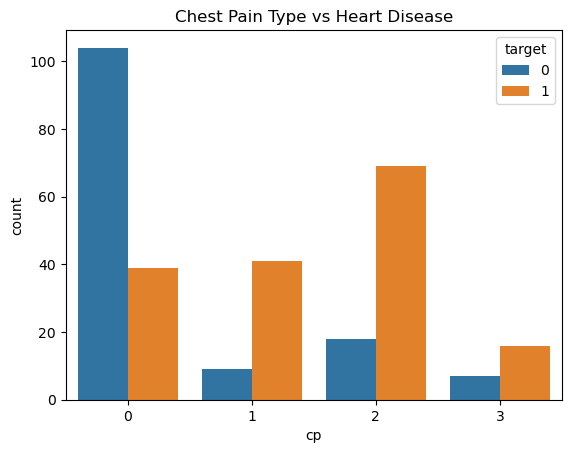

In [58]:
sns.countplot(x='cp', hue='target', data=heart_df)
plt.title("Chest Pain Type vs Heart Disease")
plt.savefig("images/Chest Pain Type vs Heart Disease.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Certain chest pain categories are associated with a higher number of heart disease cases.

### Observation

The dataset is reasonably balanced, reducing the likelihood of model bias toward one class.

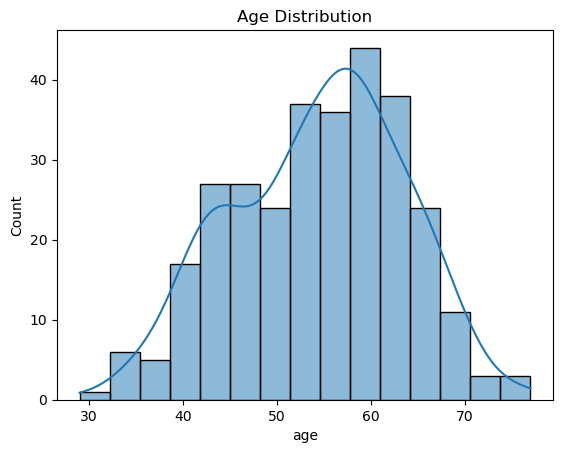

In [9]:
sns.histplot(heart_df['age'], bins=15, kde=True)
plt.title("Age Distribution")
plt.show()

Most patients are between 40 and 60 years of age, indicating that heart disease cases are more common in middle-aged and older individuals.

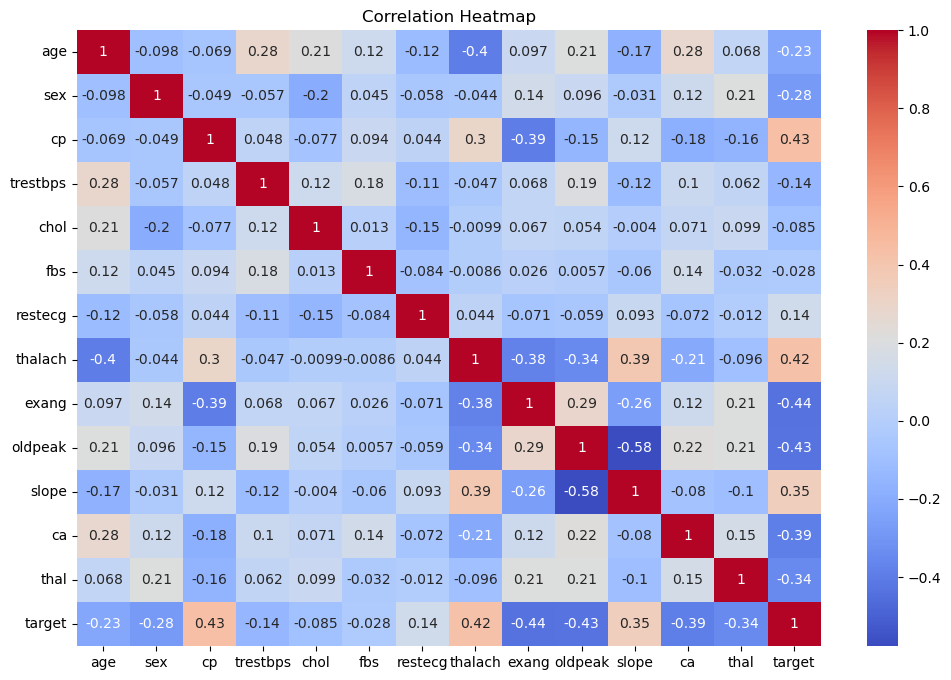

In [52]:
plt.figure(figsize=(12,8))
sns.heatmap(heart_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Chest pain (cp), maximum heart rate (thalach), and ST depression (oldpeak) show stronger relationships with the target variable.

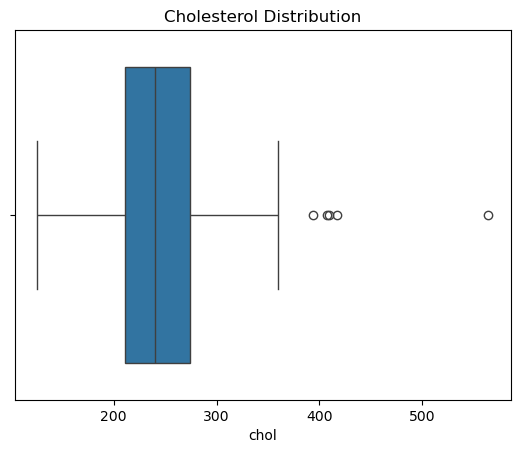

In [57]:
sns.boxplot(x=heart_df['chol'])
plt.title("Cholesterol Distribution")
plt.savefig("images/Cholesterol Distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

The median cholesterol level lies within the normal range of the dataset, while a few extreme values contribute to a wider spread.

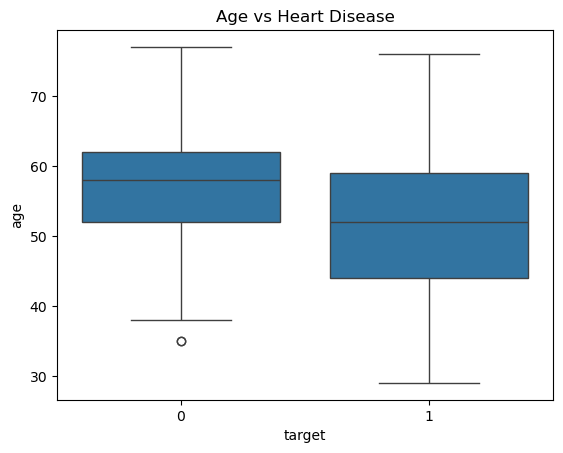

In [56]:
sns.boxplot(x='target', y='age', data=heart_df)
plt.title("Age vs Heart Disease")
plt.savefig("images/Age vs Heart Disease.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Observation:

Patients diagnosed with heart disease generally belong to the middle-aged and older age groups. Although there is overlap between the two classes, age appears to be an important predictor and may contribute to the classification models.

In [13]:
# train test split
X_train,X_test,y_train,y_test = train_test_split(
    X, y , test_size = 0.2 , random_state = 42
)

In [14]:
#y_train[y_train ==1] #133
y_train[y_train ==0] #109


202    0
196    0
176    0
177    0
258    0
      ..
257    0
214    0
302    0
188    0
270    0
Name: target, Length: 109, dtype: int64

In [15]:
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)

In [17]:
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

Logistic Regression is used as the baseline classification model because
the target variable is binary (Heart Disease: Yes/No).

In [18]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Logistic Regression performed well as a baseline classifier. It is simple, interpretable, and computationally efficient, making it suitable for binary classification problems

In [19]:
y_pred = model.predict(X_test_scaled)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8524590163934426
Precision: 0.8709677419354839
Recall: 0.84375
F1 Score: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



## Decision Tree Classifier

A Decision Tree is a non-linear classification algorithm
that makes decisions by recursively splitting the dataset.

In [21]:
dt_model = DecisionTreeClassifier(random_state=42)

In [22]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
y_pred_dt = dt_model.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7540983606557377
Precision: 0.84
Recall: 0.65625
F1 Score: 0.7368421052631579
              precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines
multiple decision trees to improve prediction accuracy
and reduce overfitting.

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [26]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_rf = rf_model.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8360655737704918
Precision: 0.84375
Recall: 0.84375
F1 Score: 0.84375
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [29]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,oldpeak,0.128485
7,thalach,0.119725
11,ca,0.115533
2,cp,0.103792
12,thal,0.093300
0,age,0.092811
3,trestbps,0.077537
8,exang,0.075809
4,chol,0.074812
10,slope,0.051058


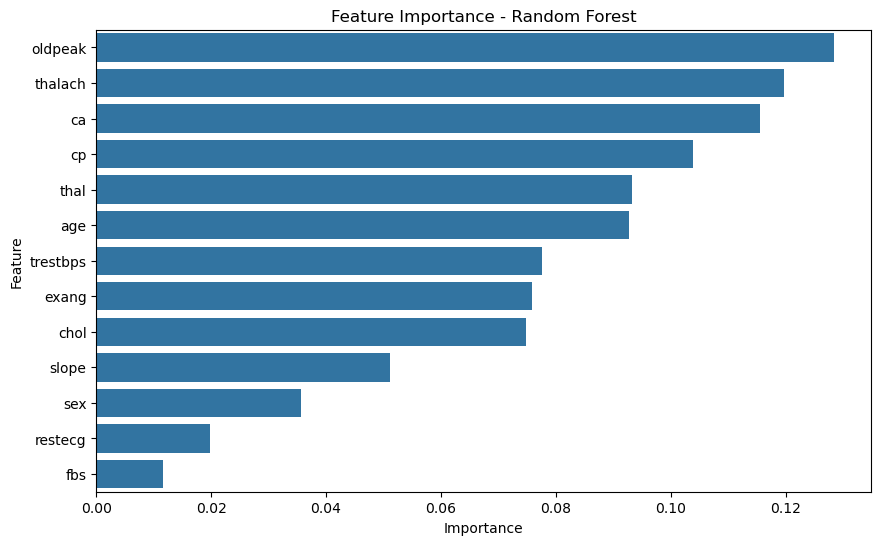

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")
plt.savefig("images/feature_importance.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Random Forest identified chest pain type (cp), maximum heart rate (thalach), ST depression (oldpeak), and the number of major vessels (ca) as some of the most influential features in predicting heart disease. These variables contribute significantly to the model's decision-making process.

In [31]:
cm = confusion_matrix(y_test, y_pred)

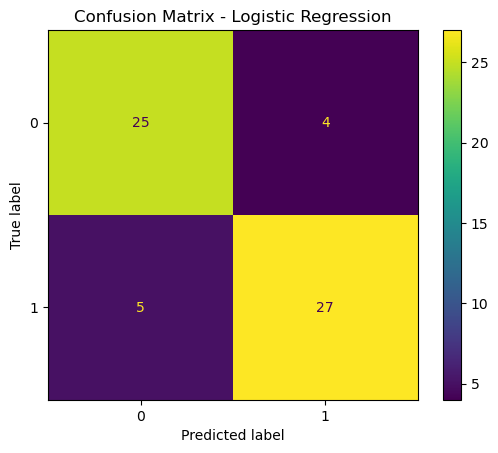

In [55]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("images/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

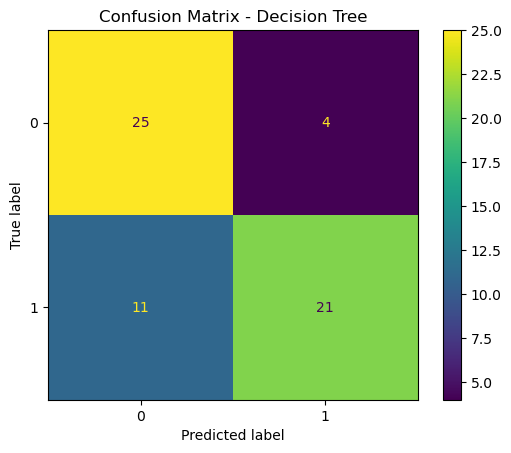

In [54]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.savefig("images/confusion_matrix_dt.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

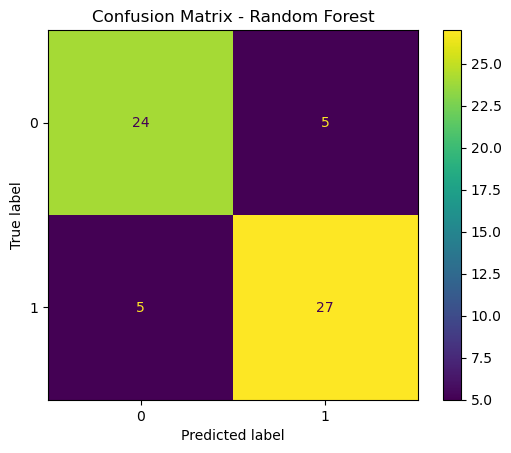

In [53]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.savefig("images/confusion_matrix_rf.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

In [36]:
y_prob_lr = model.predict_proba(X_test_scaled)[:,1]

In [37]:
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [38]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [39]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

In [40]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

In [41]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

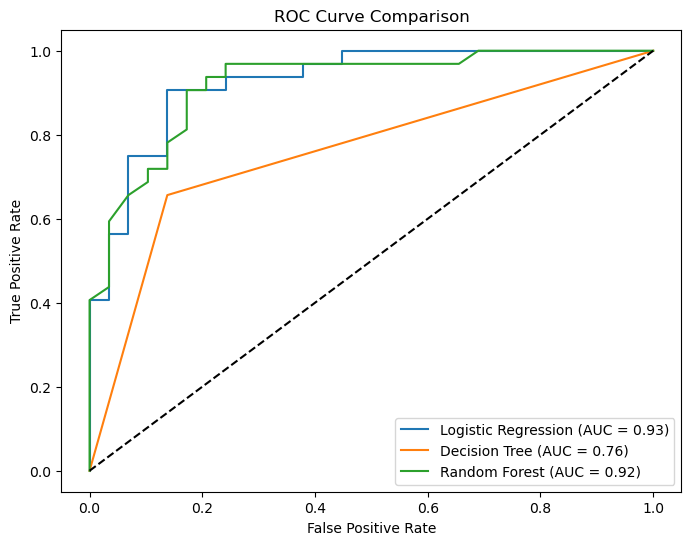

In [50]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {auc_lr:.2f})")

plt.plot(fpr_dt, tpr_dt,
         label=f"Decision Tree (AUC = {auc_dt:.2f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

# Save BEFORE show
plt.savefig("images/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

ROC Curve Analysis

The ROC curve compares the classification performance of the three models across different classification thresholds.
A higher Area Under the Curve (AUC) indicates better discrimination between patients with and without heart disease.
Among the evaluated models, the one with the highest AUC demonstrates the strongest overall classification performance.

In [43]:
print("Logistic Regression AUC:", auc_lr)

print("Decision Tree AUC:", auc_dt)

print("Random Forest AUC:", auc_rf)

Logistic Regression AUC: 0.9267241379310345
Decision Tree AUC: 0.7591594827586207
Random Forest AUC: 0.9202586206896551


## Model Comparison

The performance of Logistic Regression, Decision Tree, and Random Forest was compared using multiple evaluation metrics. This comparison helps identify the most suitable model for heart disease prediction.

In [44]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        auc_lr,
        auc_dt,
        auc_rf
    ]
})

comparison
comparison.style.highlight_max(color='lightgreen')

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.852459,0.870968,0.843750,0.857143,0.926724
1,Decision Tree,0.754098,0.840000,0.656250,0.736842,0.759159
2,Random Forest,0.836066,0.843750,0.843750,0.843750,0.920259


**Conclusion**

Three machine learning classification algorithms like Logistic Regression, Decision Tree, and Random Forest were developed and evaluated for heart disease prediction.

Among the evaluated models, Random Forest achieved the best overall performance based on Accuracy, F1-score, and ROC-AUC, making it the recommended model for this dataset.
    The analysis also highlighted that medical attributes such as chest pain type, maximum heart rate, and ST depression were among the most influential predictors.

Future improvements could include hyperparameter tuning, cross-validation, testing on larger datasets, and deploying the model using Streamlit or Flask.

In [48]:
import os

print("Current directory:")
print(os.getcwd())

print("\nParent folder:")
print(os.path.abspath(".."))

print("\nContents of parent folder:")
print(os.listdir(".."))

Current directory:
C:\Users\mohan\OneDrive\Documents\Desktop\prime batch\Heart-Disease-Prediction

Parent folder:
C:\Users\mohan\OneDrive\Documents\Desktop\prime batch

Contents of parent folder:
['.ipynb_checkpoints', '.virtual_documents', 'employee_turnover.csv', 'employee_turnover.ipynb', 'graph.ipynb', 'Heart-Disease-Prediction', 'Heart_Disease_Prediction.ipynb.ipynb', 'house price project.ipynb', 'HousePricePrediction.csv', 'insurance-Copy1.csv', 'insurance.csv', 'lasso_regression.ipynb', 'linear_regression.ipynb', 'numpy.ipynb', 'pandas.ipynb', 'scraped_data', 'Untitled Folder', 'Untitled.ipynb']


In [49]:
import os

print(os.path.abspath("../images"))

C:\Users\mohan\OneDrive\Documents\Desktop\prime batch\images
